In [8]:
import pandas as pd
import numpy as np
import sklearn
from scipy.sparse import spmatrix
from typing import Dict
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt


<Axes: xlabel='label'>

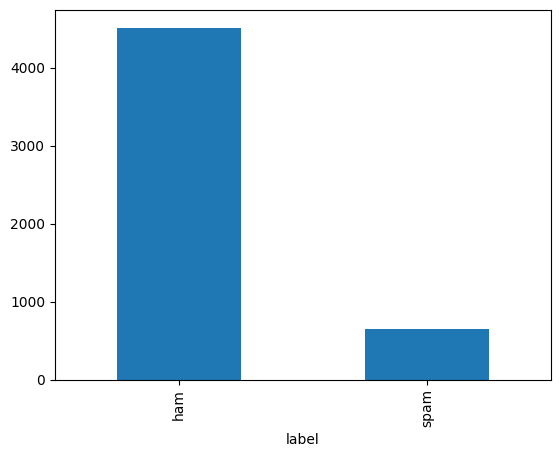

In [9]:
df: pd.DataFrame = pd.read_csv("spamhamdata.csv", sep="\t", names=["label", "message"])

df.drop_duplicates(inplace=True)
df.label.value_counts().plot.bar()

In [10]:
vectoriser: CountVectorizer = CountVectorizer(stop_words='english')

X: spmatrix = vectoriser.fit_transform(df['message'])
y: pd.Series = df['label'].map({"spam": 1, "ham": 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
model: sklearn.base.ClassifierMixin = MultinomialNB() 
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [12]:
param_grid: Dict[np.array, list] = {
    'alpha': [0.1, 0.5, 1.0, 2.0],
}

grid_search: GridSearchCV = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, verbose=True)

grid_search.fit(X_train,y_train)

print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)
print(grid_search.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
best accuracy 0.9823458282950422
MultinomialNB(alpha=2.0)
{'alpha': 2.0}


Accuracy: 0.9806576402321083
Precision: 0.9236641221374046
Recall: 0.9236641221374046
F1 score: 0.9236641221374046


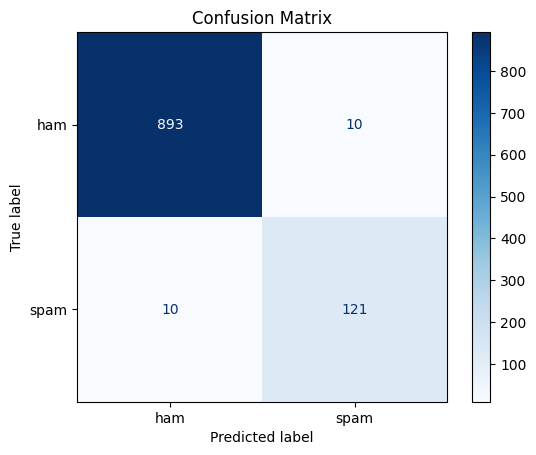

In [13]:
y_pred: np.array = grid_search.best_estimator_.predict(X_test)

accuracy: float = accuracy_score(y_test, y_pred)
precision: float = precision_score(y_test, y_pred)
recall: float = recall_score(y_test, y_pred)
f1: float = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 score: {f1}')

cm: np.array = confusion_matrix(y_test, y_pred)

display: ConfusionMatrixDisplay = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df.label.unique())
display.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()